In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import numpy as np

import utils_detuning
import utils_data

In [3]:
# --! instatiate a cavity simulator ------------------------------------------------------!

config = {
    'q_rf'       : 4e7,        # loaded quality factor
    'f_rf'       : 1.3e9,      # cavity frequency in hertz
    'v_rf'       : [10., 0.],  # generator voltage
    'pctr_on_rf' : False,      # prortional controller is on
    'K_rf'       : 100.        # proportional controller gain
}

sim = utils_detuning.detuning_sim(config)

dt = 0.01 # discretization step
ns = 0.1 # rms noise level

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


inf >> number of mechanical modes specified: 1


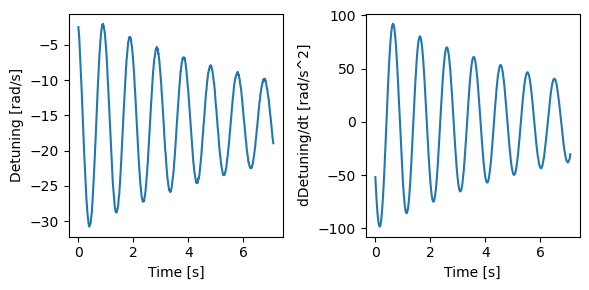

inf >> training files saved


In [4]:
# --! simulate with parameters -----------------------------------------------!

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([0.,]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
]

detuning_stat = sim(sim_param, noise=ns)

# --! display resulting detuning
for d in detuning_stat:
    sim.disp(d, timestep=dt)

datasaved = True
if datasaved:
    data_dir     = '../../data/baselines/train_sim_stat'
    data_nsample = 200
    utils_data.save_traindata(detuning_stat, data_dir, data_nsample)

## Generate transient data

inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1


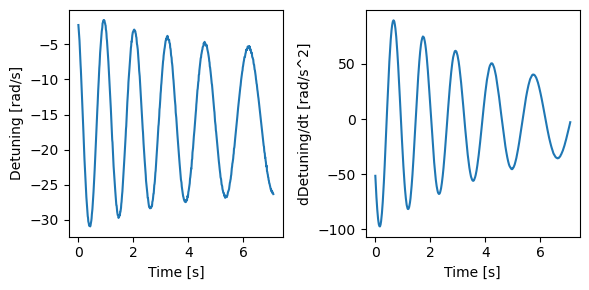

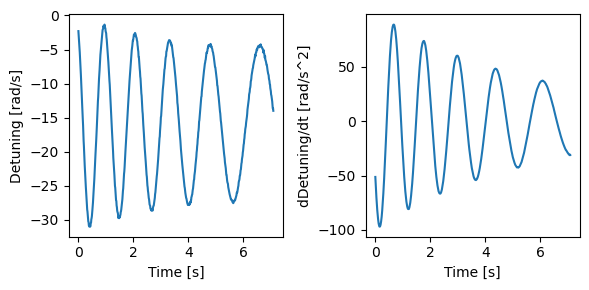

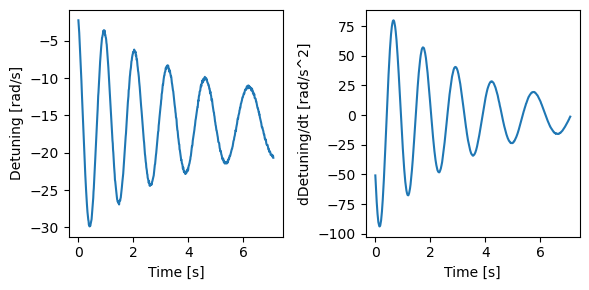

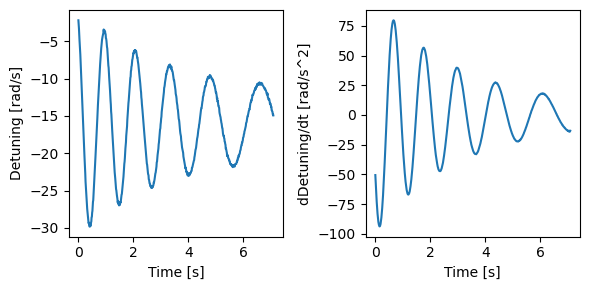

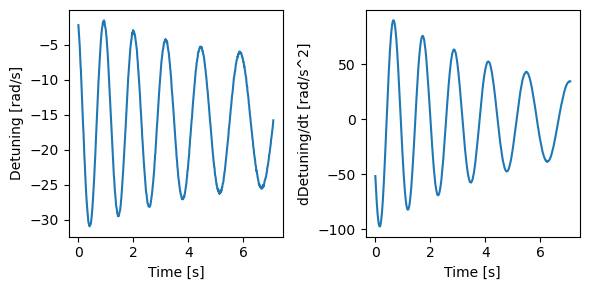

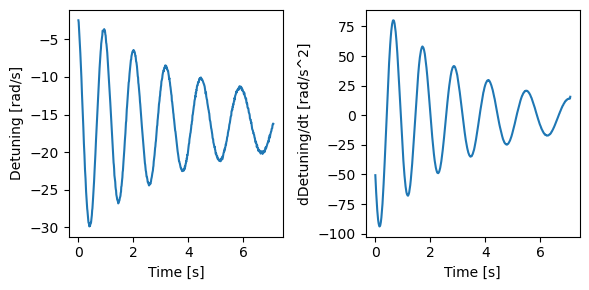

In [5]:
# --! simulate with parameters -----------------------------------------------!

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.07,]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.08,]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.07,]),
        'q_m'    : np.array([10.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.08,]),
        'q_m'    : np.array([10.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.06,]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.06,]),
        'q_m'    : np.array([10.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
]

detuning_trans = sim(sim_param, noise=ns)

# --! display resulting detuning
for d in detuning_trans:
    sim.disp(d, timestep=dt)

datasaved = False
if datasaved:
    data_dir     = '../../data/baselines/train_sim_trans'
    data_nsample = 200
    utils_data.save_traindata(detuning_trans, data_dir, data_nsample)

In [6]:
# --! compose mixed time series -----------------------------------------------!

detuning_mixed = detuning_stat + detuning_trans

datasaved = True
if datasaved:
    data_dir       = '../../data/baselines/train_sim_mixed'
    data_nsample   = 200
    utils_data.save_traindata(detuning_mixed, data_dir, data_nsample)

inf >> training files saved


inf >> number of mechanical modes specified: 1


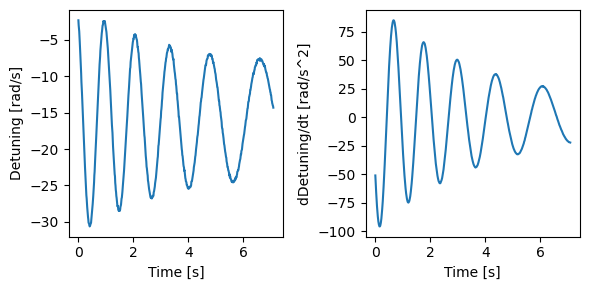

inf >> evaluation file saved


In [7]:
# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([1.]),
        'fe_m'   : np.array([-0.08]),
        'q_m'    : np.array([14.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
]

detuning_test = sim(sim_param, noise=ns)

# --! display resulting detuning
for d in detuning_test:
    sim.disp(d, timestep=dt)

# --! save timeseries
datasaved = True
if datasaved:
    data_dir     = '../../data/baselines/test_sim'
    data_nsample = 200
    utils_data.save_testdata(detuning_test, data_dir, data_nsample)